# Preprocessing
This notebook explores the preprocessing techniques that I aim to use. Specifically, I will be using STL decomposition to remove seasonality and trend from the data and assess how well the decomposition works for different kinds of data. I will generate a synthetic dataset to test the decomposition under optimal conditions and then compare the results to a dataset where one year exhibits a synthetic anomaly and also to data whose periodicity is more driven by water availability rather than radiation. I will use Mumbai precipitation data for that purpose.

In [395]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utils.event_sampling import get_data_pixel_coordinates
from utils.anomaly_score import calculate_anomaly_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# Access APIs
from xcube.core.store import new_data_store

import requests
import zipfile
import io

## 1. Create typical kNDVI time series

Can be skipped as the TS data is already saved in the data folder and computation takes very long.

### Load data

In [ ]:
# Load Earth System Data Cube store
store = new_data_store("s3", root="deep-esdl-public", storage_options=dict(anon=True))
ds_esdc = store.open_data('esdc-8d-0.25deg-1x720x1440-3.0.1.zarr')

kndvi = ds_esdc['kndvi'].sel(time=slice('2001-01-01', '2010-12-31')) # Select a 10 year window

# Load GLDA land mask
ds_landmask = xr.open_dataset("data/GLDASp5_landmask_025d.nc4")

landmask = ds_landmask['GLDAS_mask']

### Sample random locations for kNDVI time series

In [ ]:
# Get coordinates of pixels on land
land_coords = get_data_pixel_coordinates(landmask)

# Sample 68 from the Northern Hemisphere
northern_sample = land_coords[land_coords['lat'] > 0].sample(n=68, random_state=42)

# Sample 32 from the Southern Hemisphere
southern_sample = land_coords[land_coords['lat'] < 0].sample(n=32, random_state=42)

# Combine both
samples_df = pd.concat([northern_sample, southern_sample], ignore_index=True)

The samples of the southern hemisphere are shifted half a year to match the seasonality of northern hemisphere, i.e. to align the respective summer and winter seasons.

In [ ]:
ts_list = []

for _, row in samples_df.iterrows():
    lat = row['lat']
    lon = row['lon']
    
    # Extract the time series at this lat/lon point
    ts = kndvi.sel(lat=lat, lon=lon, method="nearest")
    
    if ts.isnull().all():
        continue

    # Shift Southern Hemisphere by ~6 months to align seasons
    if lat < 0:
        # Shift by 182 days
        ts['time'] = ts['time'] + pd.Timedelta(days=182)
        
        # Interpolate to match original time axis
        ts = ts.interp(time=kndvi.time)

    ts_list.append(ts)

# Stack and compute the median across all season-aligned locations
ts_stacked = xr.concat(ts_list, dim="location")


Through shifting, first and lasr 182 days of the time series are either only from the northern or southern hemisphere. Therefore, we remove these days from the time series

In [ ]:
# Calculate time bounds to exclude first and last 182 days
start_time = ts_stacked.time.values[0] + np.timedelta64(182, 'D')
end_time = ts_stacked.time.values[-1] - np.timedelta64(182, 'D')

# Subset the time series to exclude edge effects
kndvi_ts = ts_stacked.sel(time=slice(start_time, end_time))


In [ ]:
# Write to netcdf file
kndvi_ts.to_netcdf('data/ts_kndvi_10y.nc')

## 2. Load and prepare data

### 2.1 kNDVI data
The kNDVI data is already created and will be loaded in. An artificial extreme event is created by adding a negative anomaly to the kNDVI data.

In [119]:
# Import kndvi time series netcdf
ts = xr.open_dataset('data/ts_kndvi_10y.nc')

series_normal = ts['kndvi'].mean(dim="location")

# Convert to series
series_normal = series_normal.to_series()

In [325]:
# Seasonality with extreme year
series_extreme = series_normal.copy()

# Start and end date of anomaly  in summer
start_date = '2005-06-01'
end_date = '2005-07-31'

# Create date range for anomaly
anomaly_index = series_extreme.loc[start_date:end_date].index
n = len(anomaly_index)

# Generate a smooth anomaly: half-sine curve scaled to max depth
depth = 0.07  # Max amount to subtract
curve = depth * np.sin(np.linspace(0, np.pi, n))

# Subtract the curve
series_extreme.loc[anomaly_index] -= curve


/var/folders/50/66mz5mzd0k7gz3g2z0y80mlc0000gn/T/ipykernel_1199/1875046602.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.2297903  0.21730929 0.20602327 0.20848351 0.22207813 0.25140959
 0.28720683]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  series_extreme.loc[anomaly_index] -= curve


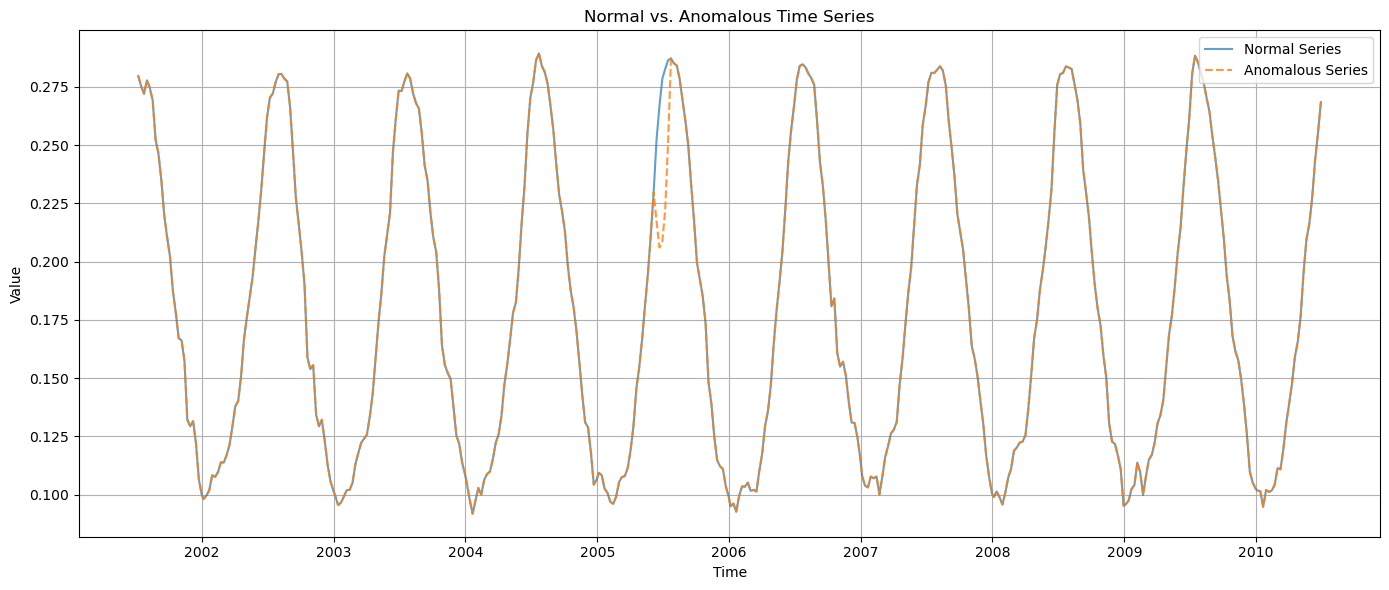

In [326]:
# Plot both series
plt.figure(figsize=(14, 6))
plt.plot(series_normal.index, series_normal, label='Normal Series', alpha=0.7)
plt.plot(series_extreme.index, series_extreme, label='Anomalous Series', alpha=0.8, linestyle='--')

plt.title('Normal vs. Anomalous Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Seasonal decomposition of the data

In [327]:
# Synthetic normal data
dec_normal = STL(series_normal, period = 48).fit()

# Synthetic data with anomaly
dec_extreme = STL(series_extreme, period = 48).fit()

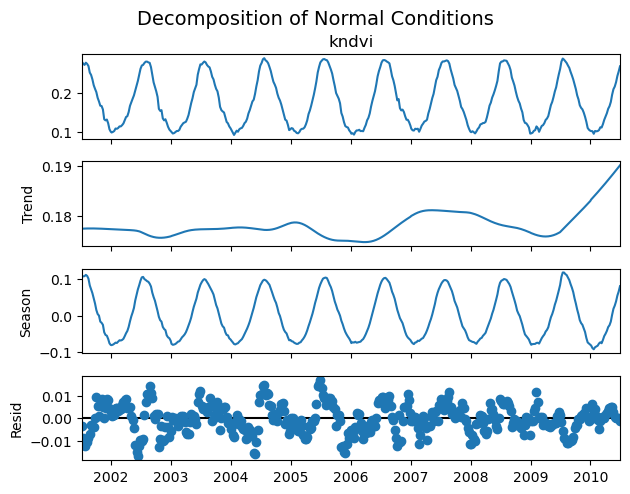

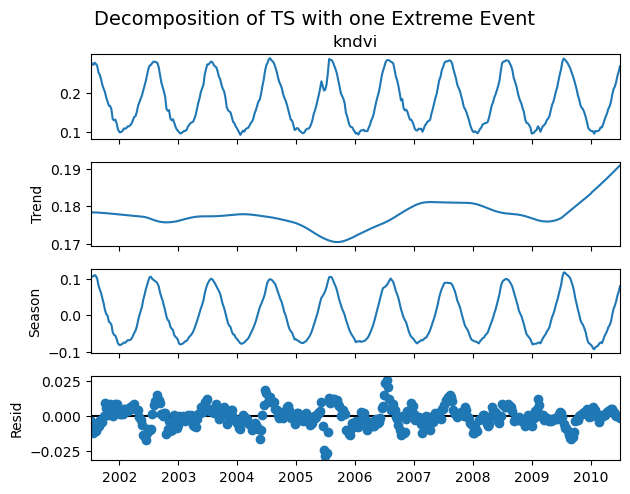

In [328]:
# Plot decompositions
fig1 = dec_normal.plot()
fig1.suptitle("Decomposition of Normal Conditions", fontsize=14, y=1.02)

fig2 = dec_extreme.plot()
fig2.suptitle("Decomposition of TS with one Extreme Event", fontsize=14, y=1.02)

plt.show()

## 4. Test decomposition performance
- performance of decomposition on synthetic data can be assessed by quantifying the differences between the components from the normal and the anomalous TS
- residuals should be white noise, i.e. no significant autocorrelation spikes

### 4.1 Compare deviations caused by extreme event


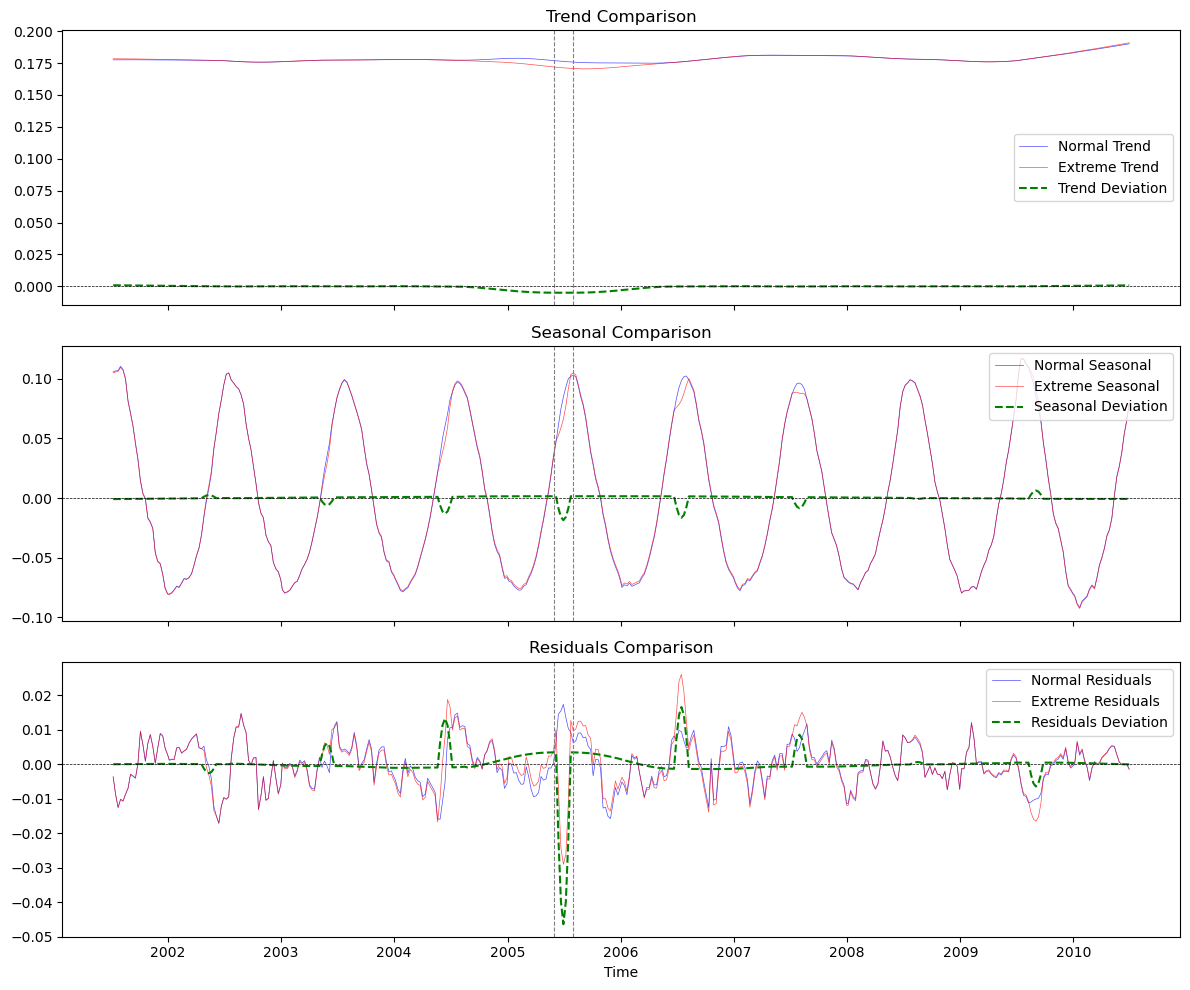

In [355]:
# Compute deviations
deviation_trend =  dec_extreme.trend - dec_normal.trend
deviation_seasonal =  dec_extreme.seasonal - dec_normal.seasonal
deviation_residuals = dec_extreme.resid - dec_normal.resid

# Create figure and axes
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot Trend
axes[0].plot(dec_normal.trend, label='Normal Trend', color='blue', alpha=0.7, linewidth=0.5)
axes[0].plot(dec_extreme.trend, label='Extreme Trend', color='red', alpha=0.7, linewidth=0.5)
axes[0].plot(deviation_trend, label='Trend Deviation', color='green', linestyle='--')
axes[0].set_title('Trend Comparison')
axes[0].legend()

# Plot Seasonal
axes[1].plot(dec_normal.seasonal, label='Normal Seasonal', color='blue', alpha=0.7, linewidth=0.5)
axes[1].plot(dec_extreme.seasonal, label='Extreme Seasonal', color='red', alpha=0.7, linewidth=0.5)
axes[1].plot(deviation_seasonal, label='Seasonal Deviation', color='green', linestyle='--')
axes[1].set_title('Seasonal Comparison')
axes[1].legend()

# Plot Residuals
axes[2].plot(dec_normal.resid, label='Normal Residuals', color='blue', alpha=0.7, linewidth=0.5)
axes[2].plot(dec_extreme.resid, label='Extreme Residuals', color='red', alpha=0.7, linewidth=0.5)
axes[2].plot(deviation_residuals, label='Residuals Deviation', color='green', linestyle='--')
axes[2].set_title('Residuals Comparison')
axes[2].legend()

plt.xlabel('Time')
for ax in axes:
    ax.axvline(start_date, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(end_date, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.2 Autocorrelation Function (ACF) of Residuals

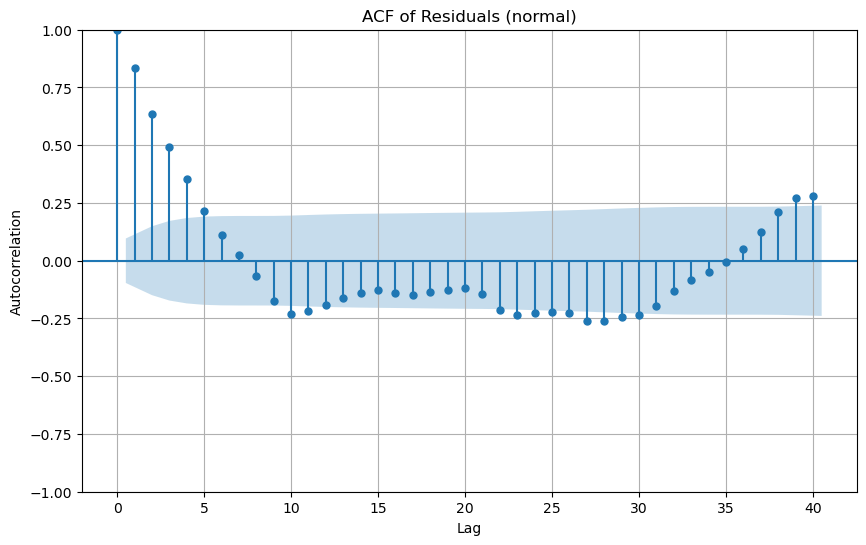

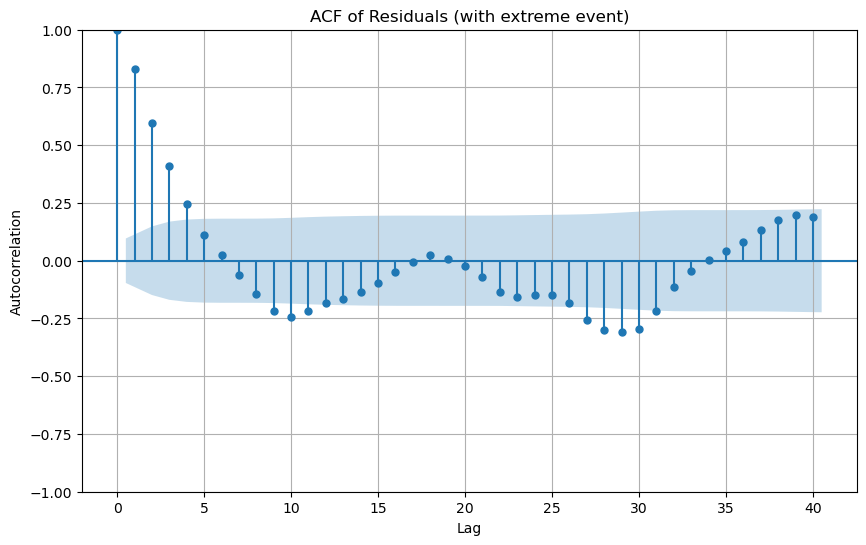

In [330]:
# Create the plot using plot_acf
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(dec_normal.resid, ax=ax, lags=40, alpha=0.05)
plt.title('ACF of Residuals (normal)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(dec_extreme.resid, ax=ax, lags=40, alpha=0.05)
plt.title('ACF of Residuals (with extreme event)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

**Synthetic without extreme event:** Almost all time lags are insignificant. lag 23 and 35 have slightly significant positive correlations and lag 25 slightly significant negative correlation.

**Synthetic with extreme event:** The plot shows seveal significant spikes which decrease first with increasing time lag, converge to 0 and then again increase but in the negative direction. This waveform may be due to the sine used to generate the synthetic data.

Interpretation of Residual Autocorrelation:

If the residuals of a time series model (like those from a decomposition) are truly white noise, their autocorrelation function should ideally show no significant correlations at any lag other than lag 0. The presence of significant autocorrelation in the residuals, as seen in this plot, suggests that there is still unexplained structure or dependence in the time series data that the decomposition model did not capture. Specifically, the significant spikes indicate that the residuals are not random and that past residual values can predict future residual values. This implies that the model might not be adequately capturing all the temporal dependencies in the original time series.

Possible Implications:

The underlying time series might have remaining seasonality or trend components that were not fully removed by the decomposition. There might be autocorrelation in the original series that the decomposition model didn't account for, indicating a need for a more sophisticated model (e.g., ARIMA or similar models) if the goal is to model and forecast the series. The presence of significant spikes at specific lags could suggest yearly or half-yearly seasonality that was not captured or fully removed by the decomposition if the data is, for example, monthly or bi-weekly.

## 5. Decomposition optimization
The TS with an extreme event in one year is far of from the non-anomalous TS. Thus, optimization is required. The robust parameter of the STL decomposition can be used to reduce the impact of the extreme event.

Objective:
The core of anomaly detection in time series analysis is to identify data points that deviate significantly from the expected pattern.
- reduce deviation from trend and seasonal component between the normal and anomalous TS
- ensuring that extreme events signal is retained in the residuals

 ### 5.2 Bayesian optimization

The objective can be met by minimizing the errors between trend and seasonal components of the normal and extreme TS decompositions. For the residuals, autocorrelation should be minimal for undisturbed time series as well as minimal for the anomalous time series outside of the anomalous period. The residuals inside of the anomalous period should be maximized.

In [ ]:
# Define parameter range 
param_space = {
    'seasonal': hp.quniform('seasonal', 7, 45, 2),  # 7 to 45, step of 4
    'trend': hp.quniform('trend', 47, 181, 2),        # 9 t
    'inner_iter': hp.uniform('inner_iter', 1, 2), 
    'outer_iter': hp.quniform('outer_iter', 5, 20, 5)
}

# Define objective function
def objective_function(params, series_normal, series_extreme, start_date, end_date, w_similarity=0.4, w_anomaly=0.5, w_noise=0.1):
    """
    Objective function for hyperparameter optimization.
    Returns the weighted sum of the similarity, anomaly, and noise scores.

    Parameters:
    - params (dict): Dictionary containing the hyperparameters.
    - series_normal (pd.Series): The normal time series.
    - series_extreme (pd.Series): The extreme time series.
    - w_similarity (float): Weight for the similarity score.
    - w_anomaly (float): Weight for the anomaly score.
    - w_noise (float): Weight for the noise score.
    - start_date (str): Start date for the anomaly score calculation.
    - end_date (str): End date for the anomaly score calculation.

    Returns:
    - score (float): The weighted sum of the similarity, anomaly, and noise scores.
   
    """

    # Parameters
    seasonal = int(params['seasonal']) | 1
    trend = int(params['trend']) | 1
    inner_iter = int(params['inner_iter'])
    outer_iter = int(params['outer_iter'])

    # Decomposition
    decomp_normal = STL(series_normal, period = 46, seasonal=seasonal, trend=trend, robust=True).fit(inner_iter=inner_iter, outer_iter=outer_iter)
    decomp_extreme = STL(series_extreme, period = 46, seasonal=seasonal, trend=trend, robust=True).fit(inner_iter=inner_iter, outer_iter=outer_iter)

    # Extract components
    trend_normal = decomp_normal.trend
    seasonal_normal = decomp_normal.seasonal
    residuals_normal = decomp_normal.resid

    trend_extreme = decomp_extreme.trend
    seasonal_extreme = decomp_extreme.seasonal
    residuals_extreme = decomp_extreme.resid

    # Calculate lower and upper bounds for RMSE normalization
    combined_trend = np.concatenate([trend_normal, trend_extreme]) # Min and max of combined trend and seasonal components is required
    min_trend = combined_trend.min()
    max_trend = combined_trend.max()

    combined_seasonal = np.concatenate([seasonal_normal, seasonal_extreme])
    min_seasonal = combined_seasonal.min()
    max_seasonal = combined_seasonal.max()

    # Compute scores
    trend_sim_score = np.sqrt(mean_squared_error(trend_normal, trend_extreme)) / (max_trend - min_trend) # RMSE penalizes large deviations more
    seasonal_sim_score = np.sqrt(mean_squared_error(seasonal_normal, seasonal_extreme)) / (max_seasonal - min_seasonal)
    anomaly_strength_score = calculate_anomaly_score(residuals_normal, residuals_extreme, start_date, end_date)
    ljung_box_score = acorr_ljungbox(residuals_normal, lags=[10], return_df=True)['lb_pvalue'].iloc[0] 

    score = (w_similarity * (trend_sim_score + seasonal_sim_score) +
             w_anomaly * (1 - anomaly_strength_score) + 
             w_noise * (1 - ljung_box_score))

    return {'loss': score, 'status': STATUS_OK}


In [386]:
# Store results
trials = Trials()

# Run optimization
best_hyperparams = fmin(
    fn = lambda params: objective_function(
        params,
        series_normal=series_normal,
        series_extreme=series_extreme,
        start_date=start_date,
        end_date=end_date
    ),
    space = param_space,
    algo = tpe.suggest,
    max_evals = 100,
    trials = trials
)

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 100/100 [00:15<00:00,  6.52trial/s, best loss: 0.4027274238637387]


#### Plot loss over iteration

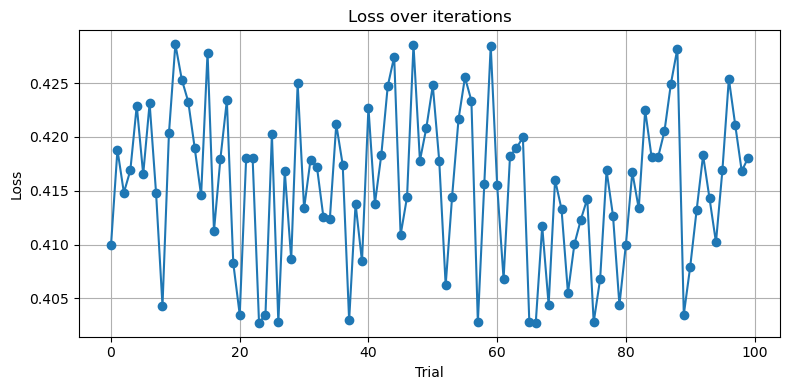

In [387]:
losses = [trial['result']['loss'] for trial in trials.trials]

plt.figure(figsize=(8, 4))
plt.plot(losses, marker='o')
plt.title('Loss over iterations')
plt.xlabel('Trial')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


#### Plot parameter values vs. loss

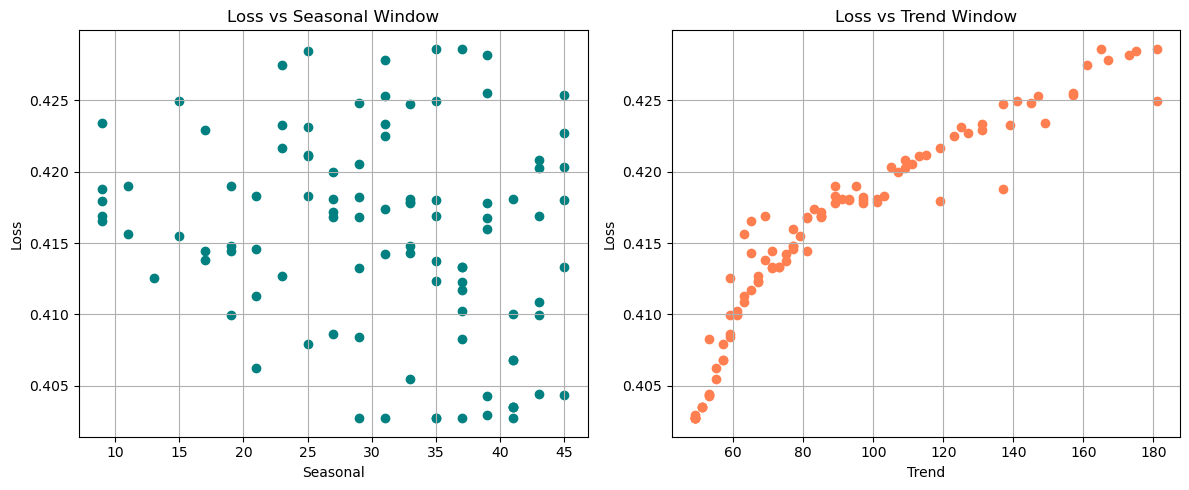

In [388]:
# Convert trials to a DataFrame
results_df = pd.DataFrame([
    {
        'seasonal': int(trial['misc']['vals']['seasonal'][0]) | 1,
        'trend': int(trial['misc']['vals']['trend'][0]) | 1,
        'loss': trial['result']['loss']
    }
    for trial in trials.trials
])

# Plot seasonal vs loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(results_df['seasonal'], results_df['loss'], color='teal')
plt.title('Loss vs Seasonal Window')
plt.xlabel('Seasonal')
plt.ylabel('Loss')
plt.grid(True)

# Plot trend vs loss
plt.subplot(1, 2, 2)
plt.scatter(results_df['trend'], results_df['loss'], color='coral')
plt.title('Loss vs Trend Window')
plt.xlabel('Trend')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

#### Show best parameters

In [390]:
print("Best hyperparameters found:")
for k, v in best_hyperparams.items():
    print(f"{k}: {int(v) | 1}")  # Ensure odd integer


Best hyperparameters found:
inner_iter: 1
outer_iter: 21
seasonal: 41
trend: 49


Visual check of optimization results:

In [391]:
# Define best parameters based on optimization
seasonal = int(best_hyperparams['seasonal']) | 1
trend = int(best_hyperparams['trend']) | 1
inner_iter= int(best_hyperparams['inner_iter']) | 1
outer_iter= int(best_hyperparams['outer_iter']) | 1

# Decomposition
decomp_normal = STL(series_normal, period = 46, seasonal=seasonal, trend=trend, robust=True).fit(inner_iter=inner_iter, outer_iter=outer_iter)
decomp_extreme = STL(series_extreme, period = 46, seasonal=seasonal, trend=trend, robust=True).fit(inner_iter=inner_iter, outer_iter=outer_iter)

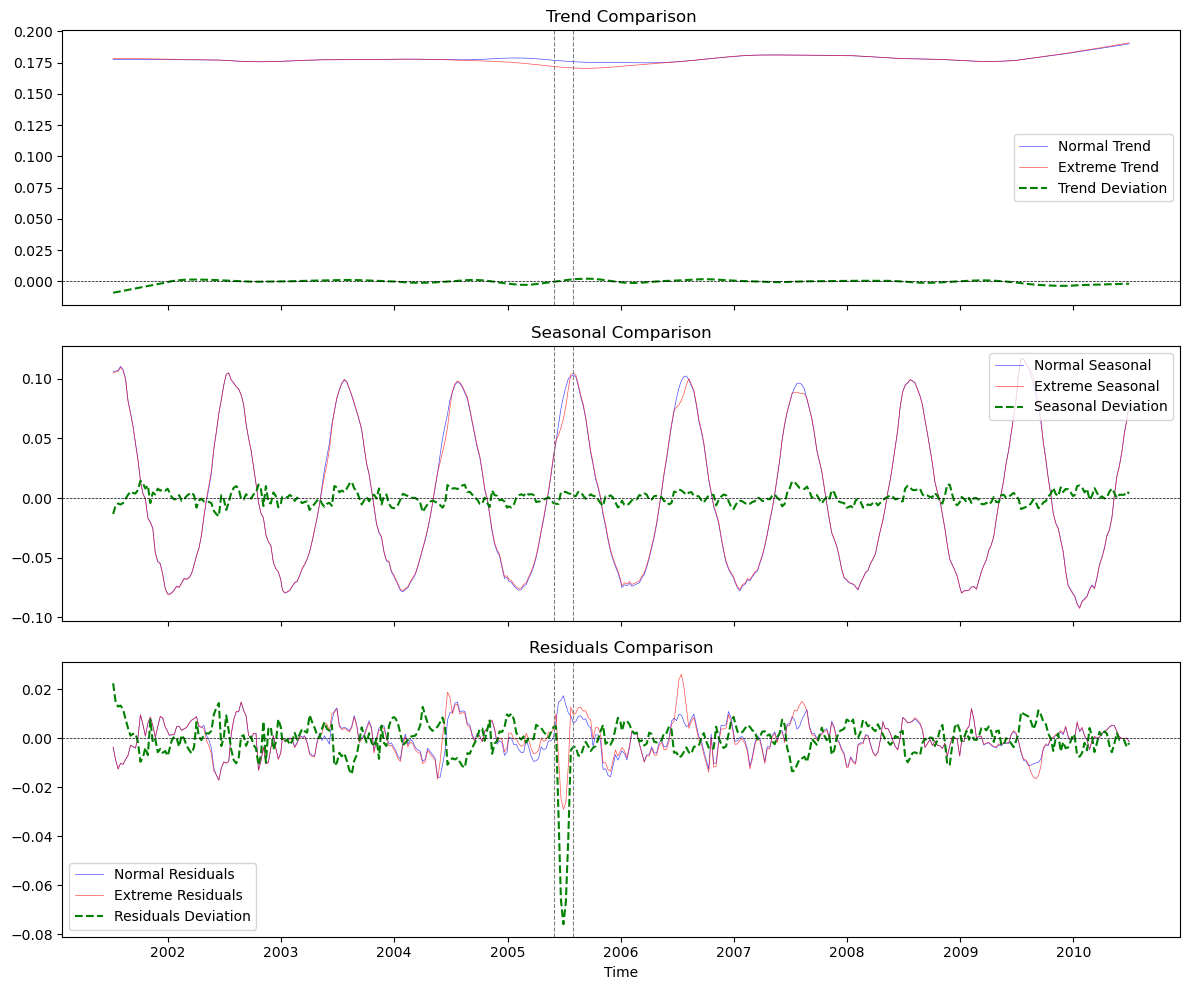

In [392]:
# Compute deviations
deviation_trend =  decomp_extreme.trend - dec_normal.trend
deviation_seasonal =  decomp_extreme.seasonal - dec_normal.seasonal
deviation_residuals = decomp_extreme.resid - dec_normal.resid

# Create figure and axes
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot Trend
axes[0].plot(dec_normal.trend, label='Normal Trend', color='blue', alpha=0.7, linewidth=0.5)
axes[0].plot(dec_extreme.trend, label='Extreme Trend', color='red', alpha=0.7, linewidth=0.5)
axes[0].plot(deviation_trend, label='Trend Deviation', color='green', linestyle='--')
axes[0].set_title('Trend Comparison')
axes[0].legend()

# Plot Seasonal
axes[1].plot(dec_normal.seasonal, label='Normal Seasonal', color='blue', alpha=0.7, linewidth=0.5)
axes[1].plot(dec_extreme.seasonal, label='Extreme Seasonal', color='red', alpha=0.7, linewidth=0.5)
axes[1].plot(deviation_seasonal, label='Seasonal Deviation', color='green', linestyle='--')
axes[1].set_title('Seasonal Comparison')
axes[1].legend()

# Plot Residuals
axes[2].plot(dec_normal.resid, label='Normal Residuals', color='blue', alpha=0.7, linewidth=0.5)
axes[2].plot(dec_extreme.resid, label='Extreme Residuals', color='red', alpha=0.7, linewidth=0.5)
axes[2].plot(deviation_residuals, label='Residuals Deviation', color='green', linestyle='--')
axes[2].set_title('Residuals Comparison')
axes[2].legend()

plt.xlabel('Time')
for ax in axes:
    ax.axvline(start_date, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(end_date, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

**Don't forget to test the found parameters on the acutal Dheed data later on.** 